# 01 — Exploratory Data Analysis : CIC-IDS2017

**Objectifs de ce notebook :**
1. Charger les fichiers CSV bruts du dataset CIC-IDS2017
2. Comprendre la structure : nombre de lignes, colonnes, features
3. Identifier les classes (Benign vs attaques) et leur distribution
4. Détecter les problèmes : valeurs manquantes, infinis, doublons
5. Première intuition des features les plus discriminantes

**Livrable attendu :** un résumé clair des forces et faiblesses du dataset, qui guidera le preprocessing en semaine 3.

## 1. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Config affichage
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

# Chemins
DATA_RAW = Path('../data/raw/cic-ids-2017')
print('Dossier données :', DATA_RAW.resolve())
print('Existe :', DATA_RAW.exists())

Matplotlib is building the font cache; this may take a moment.


Dossier données : C:\Users\natha\Documents\PFE\ids-xai-pfe\data\raw\cic-ids-2017
Existe : True


## 2. Inventaire des fichiers

CIC-IDS2017 est découpé en 8 fichiers correspondant à différents jours d'enregistrement :
- Lundi : trafic normal uniquement
- Mardi : Brute Force (FTP, SSH)
- Mercredi : DoS / Heartbleed
- Jeudi matin : Web Attacks
- Jeudi après-midi : Infiltration
- Vendredi matin : Botnet
- Vendredi après-midi 1 : PortScan
- Vendredi après-midi 2 : DDoS

In [2]:
csv_files = sorted(DATA_RAW.glob('*.csv'))
for f in csv_files:
    size_mb = f.stat().st_size / 1024**2
    print(f'{f.name:60s} {size_mb:>8.1f} MB')

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                 73.6 MB
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv             73.3 MB
Friday-WorkingHours-Morning.pcap_ISCX.csv                        55.6 MB
Monday-WorkingHours.pcap_ISCX.csv                               168.7 MB
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv      79.3 MB
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv           49.6 MB
Tuesday-WorkingHours.pcap_ISCX.csv                              128.8 MB
Wednesday-workingHours.pcap_ISCX.csv                            214.7 MB


## 3. Chargement et concaténation

In [3]:
dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f, low_memory=False)
    df_tmp['source_file'] = f.name
    print(f'{f.name:60s} -> {df_tmp.shape}')
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(f'\nDataset complet : {df.shape}')

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv             -> (225745, 80)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv         -> (286467, 80)
Friday-WorkingHours-Morning.pcap_ISCX.csv                    -> (191033, 80)
Monday-WorkingHours.pcap_ISCX.csv                            -> (529918, 80)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  -> (288602, 80)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv       -> (170366, 80)
Tuesday-WorkingHours.pcap_ISCX.csv                           -> (445909, 80)
Wednesday-workingHours.pcap_ISCX.csv                         -> (692703, 80)

Dataset complet : (2830743, 80)


In [4]:
# Nettoyer les noms de colonnes (espaces parasites)
df.columns = df.columns.str.strip()
print('Colonnes :')
for c in df.columns:
    print(' -', c)

Colonnes :
 - Destination Port
 - Flow Duration
 - Total Fwd Packets
 - Total Backward Packets
 - Total Length of Fwd Packets
 - Total Length of Bwd Packets
 - Fwd Packet Length Max
 - Fwd Packet Length Min
 - Fwd Packet Length Mean
 - Fwd Packet Length Std
 - Bwd Packet Length Max
 - Bwd Packet Length Min
 - Bwd Packet Length Mean
 - Bwd Packet Length Std
 - Flow Bytes/s
 - Flow Packets/s
 - Flow IAT Mean
 - Flow IAT Std
 - Flow IAT Max
 - Flow IAT Min
 - Fwd IAT Total
 - Fwd IAT Mean
 - Fwd IAT Std
 - Fwd IAT Max
 - Fwd IAT Min
 - Bwd IAT Total
 - Bwd IAT Mean
 - Bwd IAT Std
 - Bwd IAT Max
 - Bwd IAT Min
 - Fwd PSH Flags
 - Bwd PSH Flags
 - Fwd URG Flags
 - Bwd URG Flags
 - Fwd Header Length
 - Bwd Header Length
 - Fwd Packets/s
 - Bwd Packets/s
 - Min Packet Length
 - Max Packet Length
 - Packet Length Mean
 - Packet Length Std
 - Packet Length Variance
 - FIN Flag Count
 - SYN Flag Count
 - RST Flag Count
 - PSH Flag Count
 - ACK Flag Count
 - URG Flag Count
 - CWE Flag Count
 - EC

## 4. Distribution des classes

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


C:\Users\natha\AppData\Local\Temp\ipykernel_18520\1464411644.py:10: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\natha\AppData\Local\Temp\ipykernel_18520\1464411644.py:11: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig('../results/figures/01_class_distribution.png', dpi=120)
c:\Users\natha\Documents\PFE\ids-xai-pfe\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


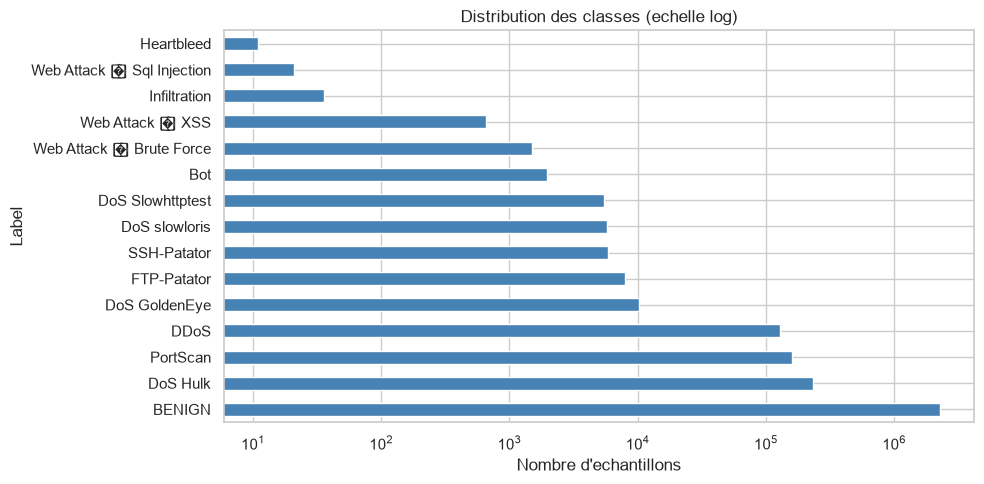

In [5]:
label_col = 'Label'
counts = df[label_col].value_counts()
print(counts)

plt.figure(figsize=(10, 5))
counts.plot(kind='barh', color='steelblue')
plt.xscale('log')
plt.title('Distribution des classes (echelle log)')
plt.xlabel('Nombre d\'echantillons')
plt.tight_layout()
plt.savefig('../results/figures/01_class_distribution.png', dpi=120)
plt.show()

## 5. Valeurs manquantes et infinies

**Attention** : CIC-IDS2017 contient des `inf` et `-inf` qui ne sont pas détectés par `isna()`. À traiter spécifiquement.

In [6]:
# Valeurs manquantes
na_summary = df.isna().sum()
print('Valeurs manquantes par colonne :')
print(na_summary[na_summary > 0].sort_values(ascending=False))

# Valeurs infinies
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_summary = np.isinf(df[numeric_cols]).sum()
print('\nValeurs infinies par colonne :')
print(inf_summary[inf_summary > 0].sort_values(ascending=False))

Valeurs manquantes par colonne :
Flow Bytes/s    1358
dtype: int64

Valeurs infinies par colonne :
Flow Packets/s    2867
Flow Bytes/s      1509
dtype: int64


## 6. Doublons

In [7]:
n_dups = df.duplicated().sum()
print(f'Nombre de doublons : {n_dups:,} ({100*n_dups/len(df):.2f}%)')

Nombre de doublons : 256,479 (9.06%)


## 7. Statistiques descriptives

In [8]:
df.describe().T.head(20)

c:\Users\natha\Documents\PFE\ids-xai-pfe\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\natha\Documents\PFE\ids-xai-pfe\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.0,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.0,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.0,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.0,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.0,0.000000,0.000000,2.616295e+01,7.125597e+03


## 8. Conclusions et points à traiter en preprocessing

_À compléter au fil de l'exploration :_

- [ ] Nombre de classes : ...
- [ ] Déséquilibre fort entre classes : ...
- [ ] Présence de NaN dans : ...
- [ ] Présence d'infinis dans : ...
- [ ] Pourcentage de doublons : ...
- [ ] Features à supprimer (constantes, IDs, IPs) : ...
- [ ] Hypothèses sur les features les plus discriminantes : ...